## Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ast



#Reading data
df = pd.read_csv('data_jobs.csv')

#Data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df_unique = df.drop_duplicates(subset=['job_title_short','company_name'])

#### Exploring roles in the Data Field

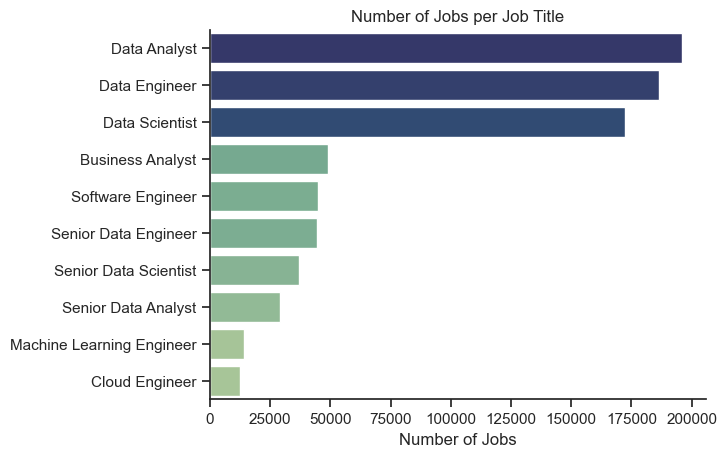

In [26]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='crest', legend=False)
sns.despine()


plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

#### Exploring the countries

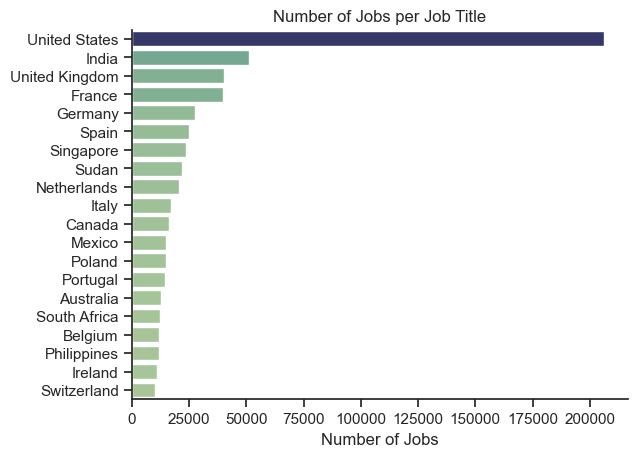

In [28]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='crest', legend=False)
sns.despine()


plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

#### Exploring the companies

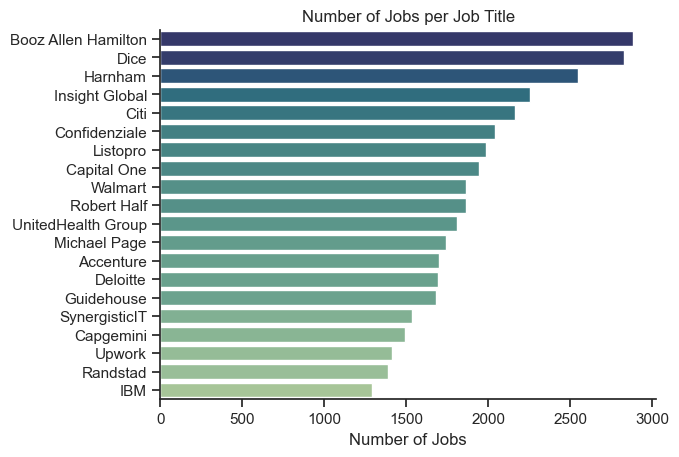

In [33]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='crest', legend=False)
sns.despine()


plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

#### Job Opportunities

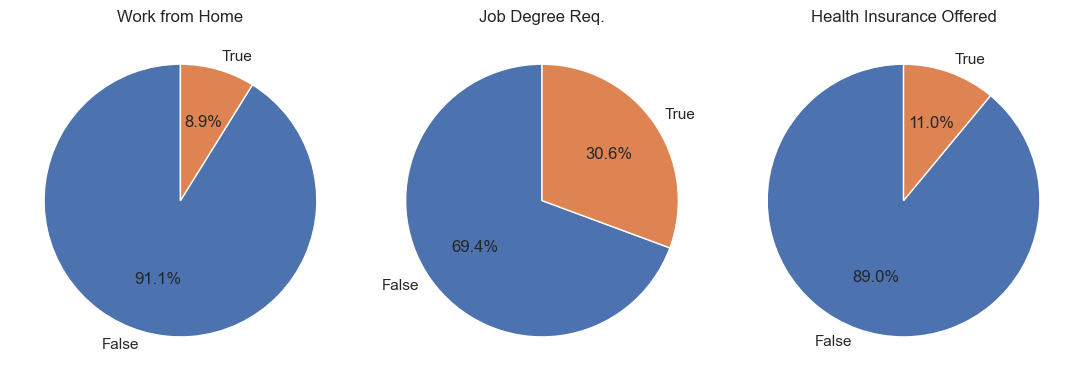

In [36]:
dict_columns = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention' : 'Job Degree Req.',
    'job_health_insurance' : 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((11,4))

for i, (column, title) in enumerate(dict_columns.items()):
    counts = df[column].value_counts()
    ax[i].pie(counts,
              startangle=90,
              autopct='%1.1f%%',
              labels=counts.index)   # ← labels vêm dos próprios dados
    ax[i].set_title(title)
plt.tight_layout()
plt.show()

### Exploratory Data Analysis for Data Analysts in the US

In [ ]:
df_DA_US = df[(df['job_country']== 'United States') & (df['job_title_short'] == 'Data Analyst')]

#### Job Opportunities

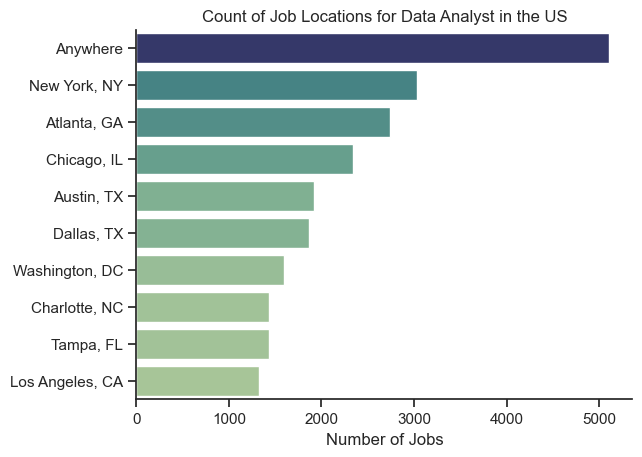

In [11]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,
            x='count',
            y='job_location',
            hue='count', palette='crest',
            legend=False)
#Formating
sns.despine()
plt.title('Count of Job Locations for Data Analyst in the US')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()

#### Companies to Explore

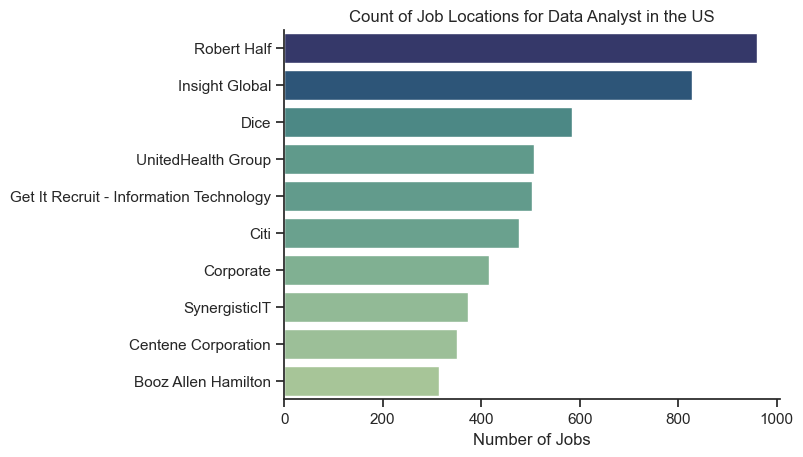

In [13]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,       
            x='count',
            y='company_name',
            hue='count', palette='crest',
            legend=False)
#Formating
sns.despine()
plt.title('Count of Job Locations for Data Analyst in the US')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()

#### Job Benefits

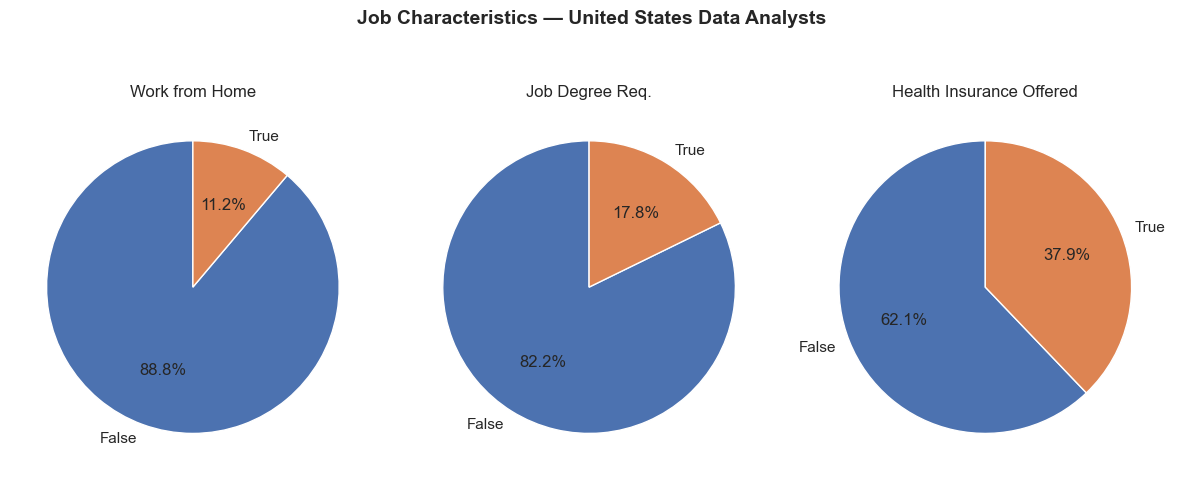

In [21]:
dict_columns = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention' : 'Job Degree Req.',
    'job_health_insurance' : 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))
fig.suptitle('Job Characteristics — United States Data Analysts',
             fontsize=14, fontweight='bold', y=1.02)  # y > 1 sobe o título acima dos subplots
for i, (column, title) in enumerate(dict_columns.items()):
    counts = df_DA_US[column].value_counts()
    ax[i].pie(counts,
              startangle=90,
              autopct='%1.1f%%',
              labels=counts.index)   # ← labels vêm dos próprios dados
    ax[i].set_title(title)
plt.tight_layout()
plt.show()